In [ ]:
import numpy as np

import glob as glob
import pickle
import sys
import re

import torch
from ili.utils.ndes_pt import LampeEnsemble
from ili.validation.metrics import PlotSinglePosterior, PosteriorCoverage
from torch_geometric.data import Data as PYGData

import matplotlib.pyplot as plt

In [3]:
# Need these things for the model to even unpickle the posterior pickle
sys.path.insert(0, '/home/puehlengt/ltu-ili/notebooks/ambe_fits')
from train_deepset import DeepSet, GraphData, apt_param_config

In [4]:
fbase = '/home/puehlengt/ltu-ili/notebooks/ambe_fits/3_param_trained_models/deepset_sweep/500totalsamples_deepset_nsf_h32_t3_emb_hs32_hl2_lr0.0003/'

# Load posterior (which contains the theta_transform)
with open(f'{fbase}/posterior.pkl', 'rb') as f:
    ensemble = pickle.load(f)
base_model = ensemble.posteriors[0] # architecture + original final weights + theta_transform + prior
base_model.eval()

LampeNPE(
  (nde): NPE(
    (flow): NSF(
      (transform): LazyComposedTransform(
        (0): MaskedAutoregressiveTransform(
          (base): MonotonicRQSTransform(bins=8)
          (order): [0, 1, 2]
          (hyper): MaskedMLP(
            (0): MaskedLinear(in_features=11, out_features=32, bias=True)
            (1): ReLU()
            (2): MaskedLinear(in_features=32, out_features=32, bias=True)
            (3): ReLU()
            (4): MaskedLinear(in_features=32, out_features=69, bias=True)
          )
        )
        (1): MaskedAutoregressiveTransform(
          (base): MonotonicRQSTransform(bins=8)
          (order): [2, 1, 0]
          (hyper): MaskedMLP(
            (0): MaskedLinear(in_features=11, out_features=32, bias=True)
            (1): ReLU()
            (2): MaskedLinear(in_features=32, out_features=32, bias=True)
            (3): ReLU()
            (4): MaskedLinear(in_features=32, out_features=69, bias=True)
          )
        )
        (2): MaskedAutoregressi

In [33]:
fchkpt_base = '/home/puehlengt/ltu-ili/notebooks/ambe_fits/3_param_trained_models/deepset_sweep/50000totalsamples_deepset_nsf_h32_t3_emb_hs32_hl2_lr0.0003'
path_bag = glob.glob(f'{fchkpt_base}/checkpoint_epoch*.pt')
path_bag.sort(key=lambda p: int(re.search(r'epoch(\d+)', p).group(1)))

epochs_available = [int(re.search(r'epoch(\d+)', p).group(1)) for p in path_bag]
print('Available epochs:', epochs_available)

Available epochs: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


In [34]:
#SELECT_EPOCH = epochs_available[-1]  # change to any epoch from the list above
SELECT_EPOCH = 70  # change to any epoch from the list above

ckpt_path = path_bag[epochs_available.index(SELECT_EPOCH)]
base_model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
base_model.eval()
print(f'Loaded epoch {SELECT_EPOCH}: {ckpt_path}')

Loaded epoch 70: /home/puehlengt/ltu-ili/notebooks/ambe_fits/3_param_trained_models/deepset_sweep/50000totalsamples_deepset_nsf_h32_t3_emb_hs32_hl2_lr0.0003/checkpoint_epoch70.pt


/tmp/ipykernel_150245/2612858951.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base_model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))


In [35]:
# Load test data
PREBUILT_PATH = '/home/puehlengt/appletree/notebooks/pyg_dataset_raw_3params.pt'
RAW_PATH      = '/home/puehlengt/appletree/notebooks/harvested_testsims_3params.npy'
N_OBS = 200

num_samples = int(re.search(r'(\d+)totalsamples', fchkpt_base).group(1))

# Load norm stats (from training data) for test set normalization
with open(f'{fchkpt_base}/norm_stats.pkl', 'rb') as f:
    norm_stats = pickle.load(f)

# Load test data
if torch.os.path.exists(PREBUILT_PATH):
    full = torch.load(PREBUILT_PATH)
    raw_test = list(full[num_samples:num_samples + N_OBS])
else:
    aa = np.load(RAW_PATH, allow_pickle=True).item()
    param_bag, events_bag = aa['param_bag'], aa['events_bag']
    raw_test = [
        PYGData(
            x=torch.tensor(events_bag[i].T),
            y=torch.tensor([v for v in param_bag[i].values()]).reshape(1, -1),
        )
        for i in range(num_samples, num_samples + N_OBS)
    ]

test_graph  = GraphData(raw_test, norm_stats['events_mean'], norm_stats['events_std'])
theta_test  = np.array([d.y.numpy().flatten() for d in raw_test])
param_names = list(apt_param_config.keys())
print(f'num_samples={num_samples}, test set size={len(raw_test)}')

/tmp/ipykernel_150245/1160099834.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  full = torch.load(PREBUILT_PATH)


num_samples=50000, test set size=200


In [36]:
posterior = LampeEnsemble(posteriors=[base_model],
                          weights=torch.tensor([1.0])) # weights of the different NN in the ensemble

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 34881.03it/s]
INFO:root:Saving single posterior plot to /home/puehlengt/ltu-ili/notebooks/ambe_fits/3_param_trained_models/deepset_sweep/500totalsamples_deepset_nsf_h32_t3_emb_hs32_hl2_lr0.0003/plot_single_posterior.jpg...


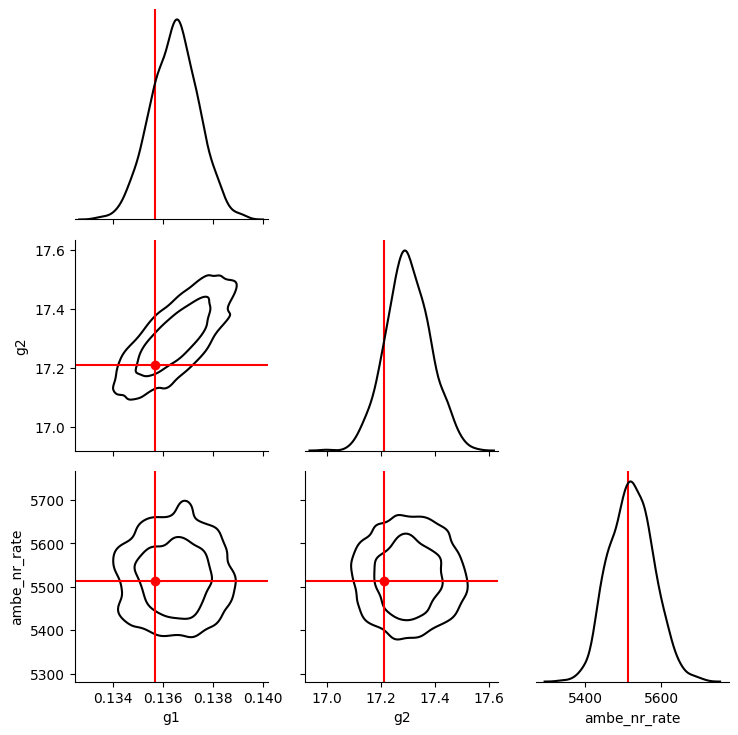

In [37]:
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct',
    labels=param_names, out_dir=fbase,
)
fig = metric(posterior=posterior, x_obs=test_graph[0], theta_fid=theta_test[0])

100%|██████████| 200/200 [00:09<00:00, 21.05it/s]
INFO:root:Saving coverage plot to /home/puehlengt/ltu-ili/notebooks/ambe_fits/3_param_trained_models/deepset_sweep/500totalsamples_deepset_nsf_h32_t3_emb_hs32_hl2_lr0.0003/plot_coverage.jpg...
INFO:root:Saving ranks histogram to /home/puehlengt/ltu-ili/notebooks/ambe_fits/3_param_trained_models/deepset_sweep/500totalsamples_deepset_nsf_h32_t3_emb_hs32_hl2_lr0.0003/ranks_histogram.jpg...
100%|██████████| 100/100 [00:00<00:00, 121.08it/s]


[<Figure size 1200x400 with 3 Axes>,
 <Figure size 900x400 with 3 Axes>,
 <Figure size 1200x400 with 3 Axes>,
 <Figure size 400x400 with 1 Axes>]

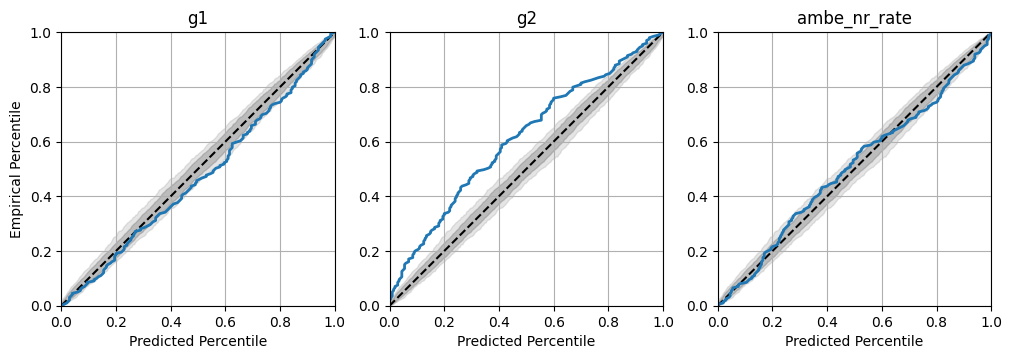

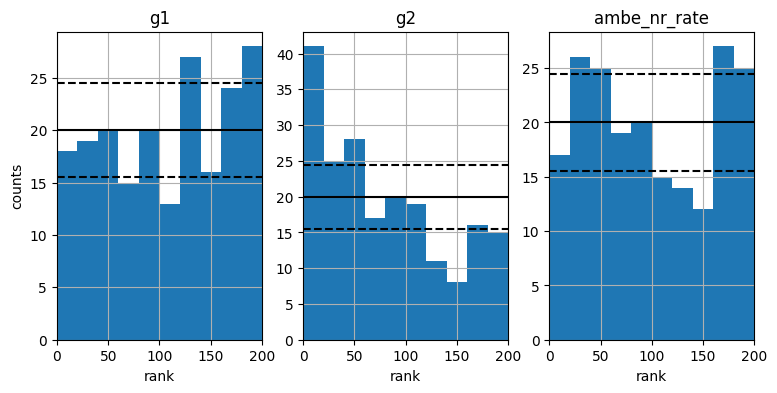

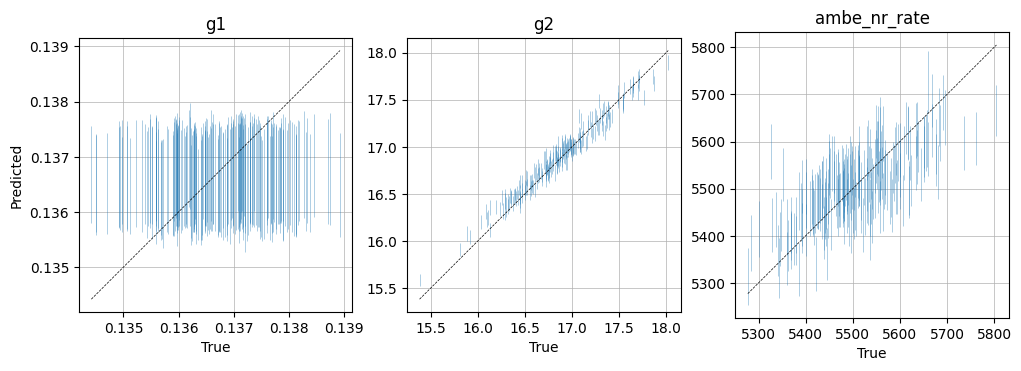

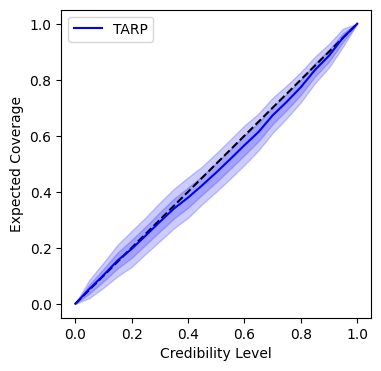

In [38]:
metric = PosteriorCoverage(
    num_samples=200, sample_method='direct',
    out_dir=fbase, labels=param_names,
    plot_list=['coverage', # PP plots
               'predictions', # pred vs truth
               'tarp', # posterior coverage??
               'histogram'], # uhhh
    save_samples=False,
)
metric(posterior=posterior, x=test_graph, theta=theta_test)